In [42]:
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import random
import tempfile
import gzip
import pylhe
import math
import csv
from scipy.optimize import curve_fit
from mpl_toolkits.mplot3d import Axes3D
from auxPlots import  xSecTest, getInfoSMS
from aux import getLHEevents, getDistributions, getInfo, getInfoSummary
from matplotlib.ticker import FixedLocator
from scipy import stats
from scipy.interpolate import PchipInterpolator

pd.option_context('display.max_columns', -1)

pd.options.mode.chained_assignment = None #Disable copy warnings
# plt.style.use('fivethirtyeight') #Set style
# mpl.rcParams.update({'figure.figsize' : (15,10)})  #Set general plotting options
plt.rcParams['figure.max_open_warning'] = 50
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set() #Set style
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']

# Extrapolating the MATRIX prediction for another binning

In [86]:
cms_bins = np.array([250.,400.,480.,560.,640.,720.,800.,900.,1000.,
                1150.,1300.,1500.,1700.,2000.,2300.,3500.])

cms_bin_widths = np.diff(cms_bins) 

def csv_reader(filename):
    output = []
    with open(filename, "r") as csvfile:
        reader = csv.reader(csvfile, delimiter=',')
        for row in reader:
            output.append(row)
    return output

def get_ratio_err(bg_ratio, bg_ratio_err):
    '''
    Convert the coordinates of the top of the error bar to the actual length of error bar
    '''
    ratio_err = []
    for i,item in enumerate(bg_ratio_err[2:]):
        ratio_err.append(float(item[1]) - float(bg_ratio[i+2][1])) #Compute the length of the upper error bar
    return ratio_err

def get_bg_error(cms_bg, data, bg_ratio_err):
    '''
    Computes the background error from the data and ratio values and errors.
    '''
    bg_err = []
    for i,item in enumerate(data[9:24]):
        data_err = np.sqrt(float(item[4])**2 + float(item[6])**2) #Considering the statistical and systematic errors
        err =  np.sqrt((bg_ratio_err[i] * float(item[3]))**2 + (data_err * cms_bg[i]/float(item[3]))**2) #computing the error
        bg_err.append(err)
    return np.array(bg_err)

def read_CMSdata(dataDir='./data', bg="MATRIX"):
    '''
    Read data and covmat from hepdata. Computes the background and its error from the ratio of the plot.
    '''
    data = csv_reader(os.path.join(dataDir,'parton_abs_ttm.csv'))
    cms_data  = []
    for item in data[9:24]:
        cms_data.append(float(item[3]))

    if bg == "MATRIX":
        bg_ratio = csv_reader(os.path.join(dataDir,'ratioMATRIX_Fig19a.csv'))
        bg_ratio_err = csv_reader(os.path.join(dataDir,'err_ratioMATRIX_Fig19a.csv')) #Coordinates of the top of the error bars
        bg_ratio_err = get_ratio_err(bg_ratio, bg_ratio_err) #Convert the coordinates in the error 
    elif bg == "MG5":
        bg_ratio = csv_reader(os.path.join(dataDir,'ratioMGPY8_Fig19a.csv'))
    else:
        print("Only MATRIX and MG5 backgrounds are available")
        
    cms_bg = []
    for i,item in enumerate(bg_ratio[2:]):
        cms_bg.append(float(item[1])*cms_data[i]) #Multiplying the ratio by the data to obtain MATRIX
    
    cms_bg_err = get_bg_error(cms_bg, data, bg_ratio_err)

    # The digitized values are multiplied by the width to get absolute expected yield per bin
    cms_bg = np.array(cms_bg)*cms_bin_widths
    cms_bg_err = np.array(cms_bg_err)*cms_bin_widths

    covdata = csv_reader(os.path.join(dataDir,'parton_abs_ttm_covariance.csv'))
    covmat = np.zeros(15*15).reshape(15,15)

    covmatlist = []
    count=0
    for item in covdata[9:234]:
        covmatlist.append(float(item[6]))

    for i in range(15):
        for j in range(15):
            covmat[i,j] = covmatlist[count]
            count+=1

    return np.array(cms_data), np.array(cms_bg), np.array(covmat), np.array(cms_bg_err)


def rebin_matrix_to_custom_bins(cms_bins, cms_bg, cms_bg_err, target_bins):
    """
    Rebins absolute yield and variance from the wide CMS binning into thinner custom binning 
    using shape-preserving PCHIP splines.
    """
    # ---------------------------------------------------------
    # Spline the Cross-Section (Yield)
    # ---------------------------------------------------------
    cdf_yield = np.insert(np.cumsum(cms_bg), 0, 0.0)
    spline_yield = PchipInterpolator(cms_bins, cdf_yield)
    
    target_cdf_yield = spline_yield(target_bins)
    target_bg = np.diff(target_cdf_yield)
    
    # ---------------------------------------------------------
    # Spline the Variance (Error squared)
    # ---------------------------------------------------------
    cms_variance = cms_bg_err**2
    cdf_variance = np.insert(np.cumsum(cms_variance), 0, 0.0)
    spline_variance = PchipInterpolator(cms_bins, cdf_variance)
    
    target_cdf_variance = spline_variance(target_bins)
    target_variance = np.diff(target_cdf_variance)
    
    # Safeguard against tiny numerical spline undershoots
    target_variance = np.clip(target_variance, 0, None)
    target_bg_err = np.sqrt(target_variance)
    
    return target_bg, target_bg_err

# ====================================================================
# HOW TO USE IT IN YOUR MAIN PLOTTING LOOP:
# ====================================================================

# 1. Read the original CMS MATRIX data once
raw_data, raw_matrix_bg, cov_matrix, raw_matrix_err = read_CMSdata(dataDir='././../Recast_CMS/data', bg="MATRIX")

# 2. Define your thin binning (e.g., from your plotting script)
my_thin_bins = np.arange(400., 3000., 50.)

# 3. Call the rebinning function!
my_matrix_bg, my_matrix_err = rebin_matrix_to_custom_bins(
    cms_bins=cms_bins, 
    cms_bg=raw_matrix_bg, 
    cms_bg_err=raw_matrix_err, 
    target_bins=my_thin_bins
)

# Now `my_matrix_bg` is an array of yields that perfectly matches your 50 GeV bin widths!

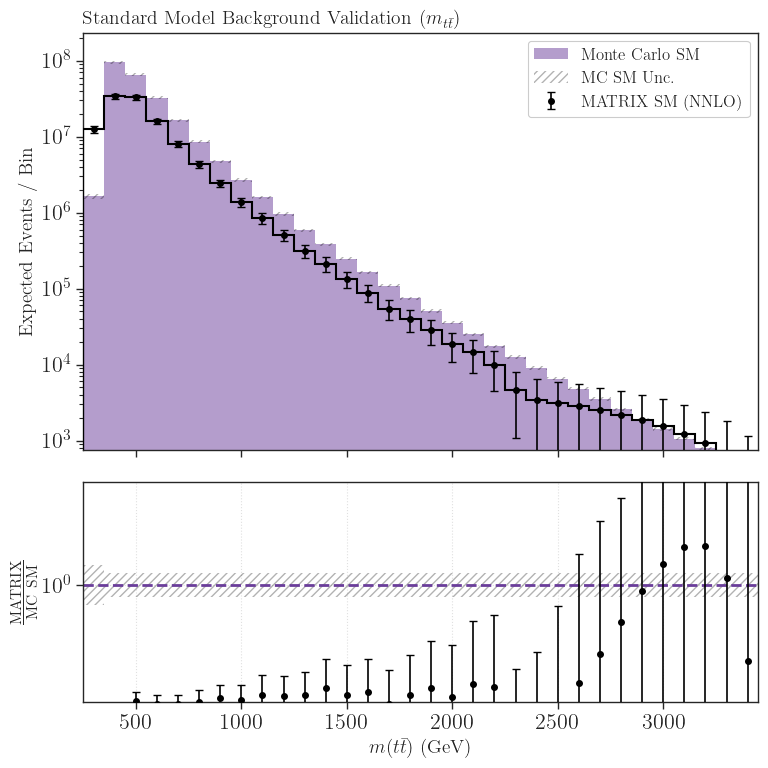

In [104]:
################
#  Physics Config
################
lum = 500 # fb^-1
lum_scale = lum * 1000.0 # Assuming weights are in pb, convert to fb

sm_err = 0.05 # 5% SM Systematic Uncertainty

# =========================================================
# 1. SETUP BINNING & EXTRACT MATRIX DATA
# =========================================================
bins = np.arange(250., 3500., 100.)
x = (bins[:-1] + bins[1:]) / 2.0
bin_widths = np.diff(bins)

# Read the raw CMS MATRIX data using the functions we just built
raw_data, raw_matrix_bg, cov_matrix, raw_matrix_err = read_CMSdata(dataDir='./../Recast_CMS/data', bg="MATRIX")

# Rebin MATRIX to perfectly match your current 'bins' array
matrix_bg, matrix_err = rebin_matrix_to_custom_bins(
    cms_bins=cms_bins, 
    cms_bg=raw_matrix_bg, 
    cms_bg_err=raw_matrix_err, 
    target_bins=bins
)

# Convert MATRIX to expected yield by scaling to your luminosity
matrix_bg_scaled = matrix_bg * lum_scale
matrix_err_scaled = matrix_err * lum_scale

# =========================================================
# 2. EXTRACT MONTE CARLO SM
# =========================================================
h_sm_raw = np.zeros(len(bins)-1)
hErr_sm_raw_sq = np.zeros(len(bins)-1)

# Loop through your MC data
for n, d in enumerate(data_sm_exp):
    h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
    hErr_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
    
    h_sm_raw += h * lum_scale
    hErr_sm_raw_sq += hErr_sq * (lum_scale**2)

h_sm = h_sm_raw / (n + 1)
hErr_sm_stat_sq = hErr_sm_raw_sq / ((n + 1)**2)
hErr_sm = np.sqrt(hErr_sm_stat_sq + (sm_err * h_sm)**2) # Including your 5% systematic

# =========================================================
# 3. PLOTTING SETUP
# =========================================================
fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=0.92, hspace=0.1)

# --- TOP PANEL: Absolute Yields ---
color_mc = sns.color_palette('Paired')[9]

# 1. Plot MC SM (Filled Histogram)
axarr[0].hist(bins[:-1], weights=h_sm, bins=bins, label='Monte Carlo SM', 
              color=color_mc, alpha=0.5, histtype='stepfilled', linewidth=0, zorder=1)

# 2. ADD MC SM ERROR BAND (Hatched Bar Plot)
axarr[0].bar(x, 2 * hErr_sm, bottom=h_sm - hErr_sm, width=bin_widths, 
             color='none', edgecolor='black', hatch='////', linewidth=0, alpha=0.3, 
             label='MC SM Unc.', zorder=2)

# 3. Plot MATRIX SM (Points with Error Bars)
color_matrix = 'black'
axarr[0].errorbar(x, matrix_bg_scaled, yerr=matrix_err_scaled, fmt='o', color=color_matrix, 
                  markersize=4, capsize=3, label='MATRIX SM (NNLO)', zorder=5)
axarr[0].hist(bins[:-1], weights=matrix_bg_scaled, bins=bins, color=color_matrix, 
              histtype='step', linewidth=1.5, zorder=4)

axarr[0].set_yscale('log')
axarr[0].set_ylabel(r'Expected Events / Bin', fontsize=14)
axarr[0].legend(framealpha=1.0, loc='upper right', fontsize=12)
axarr[0].set_xlim(bins.min(), bins.max())
axarr[0].set_title(r'Standard Model Background Validation ($m_{t\bar{t}}$)', loc='left', fontsize=14)

# --- BOTTOM PANEL: Ratio (MATRIX / MC SM) ---
with np.errstate(divide='ignore', invalid='ignore'):
    # Calculate Ratio
    ratio = matrix_bg_scaled / h_sm
    
    # Calculate relative MC error for the band
    rel_mc_err = hErr_sm / h_sm
    
    # Since MC error is in the band, ratio points should ONLY carry MATRIX error
    ratio_err = matrix_err_scaled / h_sm
    
    # Mask division by zero
    zero_mask = (h_sm <= 0)
    ratio[zero_mask] = np.nan
    ratio_err[zero_mask] = np.nan
    rel_mc_err[zero_mask] = np.nan

# Plot MC SM Error Band around 1.0 (Denominator uncertainty)
axarr[1].bar(x, 2 * rel_mc_err, bottom=1.0 - rel_mc_err, width=bin_widths, 
             color='none', edgecolor='black', hatch='////', linewidth=0, alpha=0.3, zorder=1)

# Plot a reference line at 1.0 (perfect agreement)
axarr[1].axhline(y=1.0, color=color_mc, linestyle='--', linewidth=2, zorder=2)

# Plot the ratio points (Numerator uncertainty)
axarr[1].errorbar(x, ratio, yerr=ratio_err, fmt='o', color=color_matrix, 
                  markersize=4, capsize=3, zorder=3)

axarr[1].set_ylabel(r'$\frac{\mathrm{MATRIX}}{\mathrm{MC\ SM}}$', fontsize=16)
axarr[1].set_xlabel(r'$m(t\bar{t})$ (GeV)', fontsize=14)
axarr[1].grid(True, linestyle=':', alpha=0.6)

# Set symmetric log scale to comfortably fit deviations
axarr[1].set_yscale('symlog', linthresh=1.2)
axarr[1].set_ylim(0.5, 2.0)

plt.tight_layout()
plt.show()

--- 500 fb^-1 YIELD CLOSURE TEST ---
Original MATRIX Yield: 113942150.5 events
Rebinned MATRIX Yield: 113942112.2 events
Difference: 38.3 events


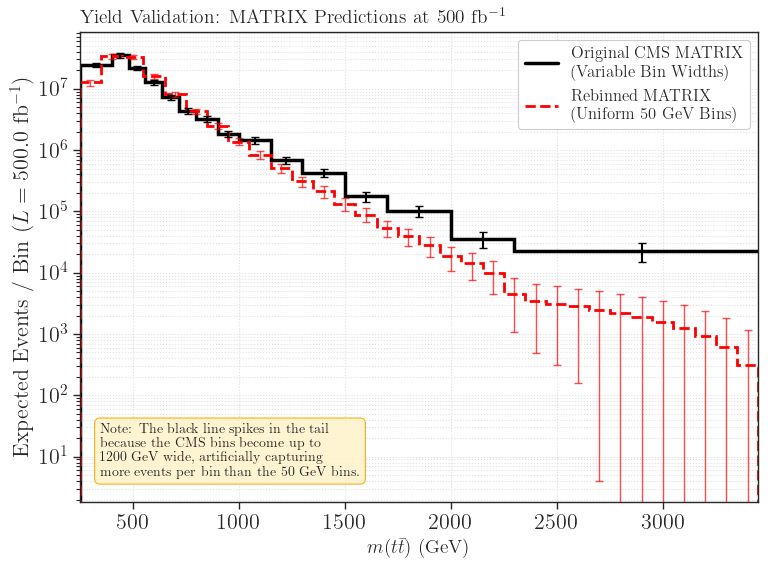

In [88]:
# ---------------------------------------------------------
# 1. Scaling to 500 fb^-1
# ---------------------------------------------------------
# If your original CMS data was an Absolute Cross Section in picobarns (pb),
# then Number of Events = Cross Section (pb) * 1000 * Luminosity (fb^-1)
lum_target = 500.0 
conversion_factor = 1000.0 # pb to fb (Change to 1.0 if the data is already in fb)

lum_multiplier = lum_target * conversion_factor

# Scale the yields (which are currently cross-sections per bin) to Total Events
cms_events = raw_matrix_bg * lum_multiplier
my_events = matrix_bg * lum_multiplier

# SCALE THE ERRORS as well!
cms_events_err = raw_matrix_err * lum_multiplier
my_events_err = matrix_err * lum_multiplier

# ---------------------------------------------------------
# 2. Check the Integrals (Total Expected Events)
# ---------------------------------------------------------
total_events_cms = np.sum(cms_events)
total_events_my = np.sum(my_events)

print(f"--- 500 fb^-1 YIELD CLOSURE TEST ---")
print(f"Original MATRIX Yield: {total_events_cms:.1f} events")
print(f"Rebinned MATRIX Yield: {total_events_my:.1f} events")
print(f"Difference: {abs(total_events_cms - total_events_my):.1f} events")

# ---------------------------------------------------------
# 3. Plot the Validation with Error Bars
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

# Calculate bin centers for placing the vertical error bars
cms_centers = (cms_bins[:-1] + cms_bins[1:]) / 2.0
my_centers = (bins[:-1] + bins[1:]) / 2.0

# Plot the original CMS MATRIX (Steps + Errors)
ax.stairs(cms_events, cms_bins, color='black', linewidth=2.5, 
          label=f'Original CMS MATRIX\n(Variable Bin Widths)')
ax.errorbar(cms_centers, cms_events, yerr=cms_events_err, fmt='none', 
            color='black', capsize=3, elinewidth=1.5, zorder=5)

# Plot your newly rebinned MATRIX (Steps + Errors)
ax.stairs(my_events, bins, color='red', linestyle='--', linewidth=2.0, 
          label=f'Rebinned MATRIX\n(Uniform 50 GeV Bins)')
ax.errorbar(my_centers, my_events, yerr=my_events_err, fmt='none', 
            color='red', capsize=3, elinewidth=1.0, alpha=0.7, zorder=4)

# Plot formatting
ax.set_yscale('log')
ax.set_xlabel(r'$m(t\bar{t})$ (GeV)', fontsize=14)
ax.set_ylabel(rf'Expected Events / Bin ($L = {lum_target}$ fb$^{{-1}}$)', fontsize=16)
ax.set_title('Yield Validation: MATRIX Predictions at 500 fb$^{-1}$', fontsize=14, loc='left')

ax.legend(fontsize=12, framealpha=1.0)
ax.grid(True, which="both", linestyle=':', alpha=0.6)

ax.set_xlim(bins.min(), bins.max())


ax.text(0.03, 0.05, warning_text, transform=ax.transAxes, 
        fontsize=10, verticalalignment='bottom', 
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff3cd', edgecolor='orange', alpha=0.9))

plt.tight_layout()
plt.show()

In [89]:
# ---------------------------------------------------------
# PROOF OF EVENT CONSERVATION
# ---------------------------------------------------------
# 1. Recreate the cumulative sum and spline using your scaled CMS events
cdf_events = np.insert(np.cumsum(cms_events), 0, 0.0)
test_spline = PchipInterpolator(cms_bins, cdf_events)

# 2. Re-evaluate the spline exactly at the original CMS edges
verification_cdf = test_spline(cms_bins)
verification_events = np.diff(verification_cdf)

print(f"{'CMS Bin (GeV)':<20} | {'Original MATRIX':<18} | {'Spline Verification'}")
print("-" * 65)

for i in range(len(cms_bins) - 1):
    bin_range = f"[{cms_bins[i]:.0f} - {cms_bins[i+1]:.0f}]"
    
    # The original events in this specific CMS bin
    orig_val = cms_events[i]
    
    # What the spline calculates for this exact same range
    spline_val = verification_events[i]
    
    print(f"{bin_range:<20} | {orig_val:<18.2f} | {spline_val:.2f}")

CMS Bin (GeV)        | Original MATRIX    | Spline Verification
-----------------------------------------------------------------
[250 - 400]          | 24578788.73        | 24578788.73
[400 - 480]          | 35260878.87        | 35260878.87
[480 - 560]          | 21773160.56        | 21773160.56
[560 - 640]          | 12730422.54        | 12730422.54
[640 - 720]          | 7283560.56         | 7283560.56
[720 - 800]          | 4371650.70         | 4371650.70
[800 - 900]          | 3237020.19         | 3237020.19
[900 - 1000]         | 1829407.51         | 1829407.51
[1000 - 1150]        | 1434738.03         | 1434738.03
[1150 - 1300]        | 679814.08          | 679814.08
[1300 - 1500]        | 425560.56          | 425560.56
[1500 - 1700]        | 177232.21          | 177232.21
[1700 - 2000]        | 101964.27          | 101964.27
[2000 - 2300]        | 35470.56           | 35470.56
[2300 - 3500]        | 22481.10           | 22481.10


# Using the extrapolated data

In [90]:
def selectColor(model, process):
    if model == 'VLF EFT':
        return sns.color_palette('Paired')[0]
    elif model == '1-loop VLF':
        return sns.color_palette('Paired')[1]
    elif model == 'Scalar EFT':
        return sns.color_palette('Paired')[2]
    elif model == 'SM':
        return sns.color_palette('Paired')[9]
    else:
        return sns.color_palette('Paired')[3]

In [91]:
def selectColor1(model, process):
    if model == '1-loop VLF':
        if process == r'$q q \to t \bar{t}$':
            return sns.color_palette("RdPu", n_colors=4 + 3)[3]
        else:
            return sns.color_palette("RdPu", n_colors=4 + 3)[4]
    elif model == '1-loop Scalar':
        if process == r'$q q \to t \bar{t}$':
            return sns.color_palette("GnBu", n_colors=4 + 3)[3]
        else:
            return sns.color_palette("GnBu", n_colors=4 + 3)[5]
    else:
        return sns.color_palette('Paired')[3]

In [92]:
def get_color_by_mass(model, mass):
    mPsiT, mSDM = mass
    
    # --- COLORS FOR VECTOR-LIKE FERMION (VLF) ---
    # Using a progression from bright blue -> dark blue -> purple
    if '1-loop VLF' in model:
        if mPsiT == 500.0 and mSDM == 375.0:
            return 'deepskyblue'   # Bright, distinct blue
        elif mPsiT == 500.0 and mSDM == 475.0:
            return 'dodgerblue'         # Standard pure blue
        elif mPsiT == 600.0 and mSDM == 475.0:
            return 'blue'         # Very dark blue
        elif mPsiT == 1500.0 and mSDM == 1425.0:
            return 'navy'   # Purple-ish blue to separate high mass
        else:
            return 'cornflowerblue' # Fallback

    # --- COLORS FOR SCALAR ---
    # Using a progression from bright green -> dark green -> teal
    elif '1-loop Scalar' in model:
        if mPsiT == 500.0 and mSDM == 375.0:
            return 'chartreuse'    # Bright, distinct green
        elif mPsiT == 500.0 and mSDM == 475.0:
            return 'limegreen'  # Standard deep green
        elif mPsiT == 600.0 and mSDM == 475.0:
            return 'forestgreen'    # Very dark green
        elif mPsiT == 1500.0 and mSDM == 1425.0:
            return 'darkgreen'         # Blue-green to separate high mass
        else:
            return 'mediumseagreen' # Fallback
    elif 'Z prime' in model:
        return sns.color_palette('Paired')[5]

    # --- DEFAULT ---
    else:
        return 'black'

In [93]:
files = list(glob.glob('/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/*/*/bias_article/*900*.npz'))
data = []
for f in files:
    aux = np.load(f, allow_pickle = True)
    data.append(aux)
print(data)    
data = sorted(data, key=lambda d: (d['mass_params'][0], d['mass_params'][1]))

[NpzFile '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/UV_BSM/gg2ttbar_gs4_ydm2/bias_article/mPsiT_1000_mSDM_900.npz' with keys: mTT, pT1, pT2, deltaPhi, weights..., NpzFile '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/UV_BSM/qq2ttbar_gs4_ydm2/bias_article/mPsiT_1000_mSDM_900_yDM_1.npz' with keys: mTT, pT1, pT2, deltaPhi, weights..., NpzFile '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/SMS_1_loop/gg2ttbar_gs4_ydm2/bias_article/mPsiT_1000_mSDM_900.npz' with keys: mTT, pT1, pT2, deltaPhi, weights..., NpzFile '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/SMS_1_loop/qq2ttbar_gs4_ydm2/bias_article/mPsiT_1000_mSDM_900.npz' with keys: mTT, pT1, pT2, deltaPhi, weights...]


In [94]:
data_NLO = []
for d in data:
    if '1-loop VLF' in d['model'] or '1-loop Scalar' in d['model']:
        data_NLO.append(d)

data_NLO = sorted(data_NLO, key=lambda d: (d['mass_params'][0], d['mass_params'][1]))

In [95]:
for d in data_NLO:
    print(d['nevents'])

874733
987244
1921354
1673512


In [96]:
#Reading files with bias
fake_data_files = list(glob.glob('/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/VLF/pp2ttbar/bias_article*/*900*.npz'))
print(fake_data_files)
fake_data = []


for f in fake_data_files:
    aux = np.load(f, allow_pickle = True)
    fake_data.append(aux)

#fake_data = sorted(fake_data, key=lambda d: (d['mPsiT'], d['mSDM']))
#print(fake_data['yDM'])
soma = 0.0
for i in fake_data:
    soma+=i['nevents']
print(soma)

['/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/VLF/pp2ttbar/bias_article_4_1000_900/mPsiT_1000_mSDM_900.npz', '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/VLF/pp2ttbar/bias_article_3_1000_900/mPsiT_1000_mSDM_900.npz', '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/VLF/pp2ttbar/bias_article_1000_900/mPsiT_1000_mSDM_900.npz', '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/VLF/pp2ttbar/bias_article_2_1000_900/mPsiT_1000_mSDM_900.npz']
7000380.0


In [97]:

files = list(glob.glob('/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/z_prime/pp2ttbar_dmv4/bias_*2000_20/*.npz'))
print(files)
#files = list(glob.glob('/home/vinicius/EFT_ToyModel/test/Distributions/*/*/*.npz'))
data_Z = []
#data_sm = []
#Loading the distributions
for f in files:
    aux = np.load(f, allow_pickle = True)
    data_Z.append(aux)

data_Z = sorted(data_Z, key=lambda d: d['mZp'])
print(data_Z[0]['xsec (pb)'])

['/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/z_prime/pp2ttbar_dmv4/bias_2000_20/mZp_2000.npz']
0.035151624


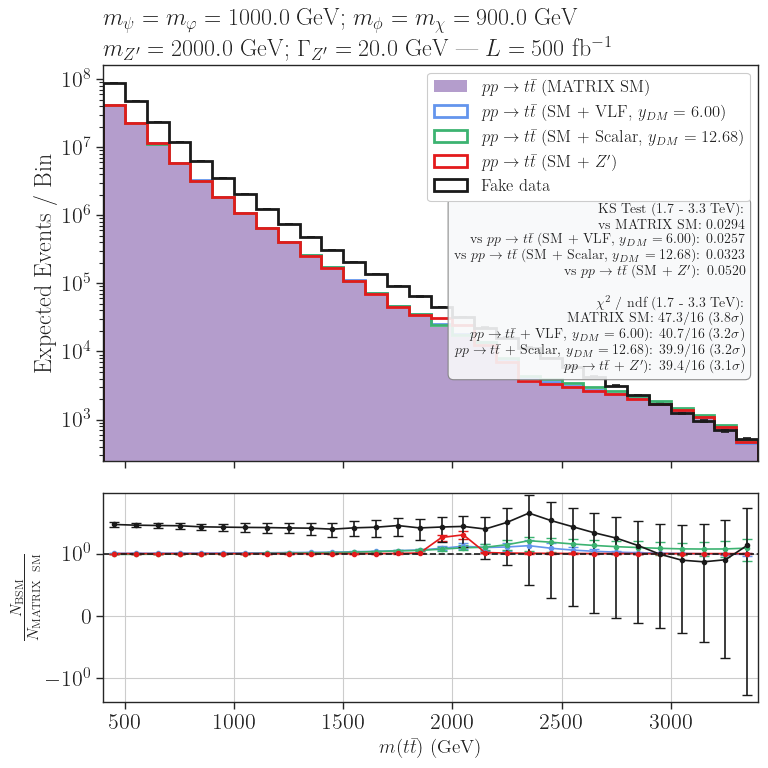

In [102]:


######################################################
#  Physics Config
######################################################
lum = 500 # fb^-1
lum_scale = lum * 1000.0 # Assuming weights are in pb, convert to fb
sm_err = 0.0 # 5% Flat SM Systematic Uncertainty

# Load the raw CMS MATRIX data ONCE before the loop
raw_data, raw_matrix_bg, cov_matrix, raw_matrix_err = read_CMSdata(dataDir='./../Recast_CMS/data', bg="MATRIX")

# Loop over the masses configurations.
for i in range(0, len(data_NLO), 4):
    selected = data_NLO[i : i+4]

    # BSM masses and couplings
    mPsiT, mSDM = selected[0]['mass_params']
    yDM = selected[0]['ydm']
    
    # --- Setup and Binning ---
    fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
    plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=0.92, wspace=None, hspace=0.1)

    if mPsiT < 600:
        bins = np.arange(400., 3000., 50.)
    elif mPsiT < 1000:
        bins = np.arange(500., 4000., 75.)
    else:
        bins = np.arange(400., 3500., 100.)
        
    x = (bins[:-1] + bins[1:]) / 2.0  
    bin_widths = np.diff(bins)

    ##############
    #  Main Plot #
    ##############
    pmodels = []
    labels_sm = []
    
    bsm_hists, bsm_histsErr = [], []
    bsm_ratios, bsm_ratio_errs, bsm_labels, bsm_colors = [], [], [], []

    # ==========================================
    # 1. Plotting and Storing the MATRIX SM 
    # ==========================================
    # Dynamically rebin MATRIX to match the current iteration's 'bins' array
    matrix_xsec_binned, matrix_xsec_err_binned = rebin_matrix_to_custom_bins(
        cms_bins, raw_matrix_bg, raw_matrix_err, bins
    )
    
    # Scale from cross-section (pb) to Yield (Events)
    h_sm = matrix_xsec_binned * lum_scale
    matrix_err_scaled = matrix_xsec_err_binned * lum_scale
    
    # Add your flat 5% systematic error in quadrature with the MATRIX theoretical error
    hErr_sm = np.sqrt(matrix_err_scaled**2 + (sm_err * h_sm)**2)
    
    process = r'$p p \to t \bar{t}$'
    model = 'MATRIX SM'
    pmodels.append(r'%s (%s)' % (process, model))
    label_sm = pmodels[-1]
    labels_sm.append(label_sm)
        
    axarr[0].hist(bins[:-1], weights=np.abs(h_sm), label=label_sm, bins=bins, density=False,
                  color=sns.color_palette('Paired')[9], alpha=0.5, histtype='step', 
                  linewidth=0, fill=True, zorder=0)

    # ==========================================
    #  Plotting the NLO BSM Data (MATRIX SM + BSM)
    # ==========================================
    y_DM = {'1-loop VLF': 6.0, '1-loop Scalar': 1.268000e+01}
    for j in range(0, len(selected), 2):
        d = selected[j]
        d_next = selected[j+1]
        
        process = r'$p p \to t \bar{t}$'
        model_raw = d['model']
        model_name = str(np.atleast_1d(model_raw)[0])
        val_y_dm = y_DM.get(model_name, 1.0)
        
        display_name = model_name.replace('1-loop ', '')
        pmodels.append(r'%s (SM + %s, $y_{DM} = %.2f$)' % (process, display_name, val_y_dm))
        label = pmodels[-1]
        
        color = get_color_by_mass(model_name, (mPsiT, mSDM))
        
        h1, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr1_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        
        h2, _ = np.histogram(d_next['mTT'], bins=bins, weights=d_next['weights'])
        hErr2_sq, _ = np.histogram(d_next['mTT'], bins=bins, weights=np.array(d_next['weights'])**2)
        
        scale_weight = y_DM.get(model_name, 1.0)**2 
        
        # APPLY LUMINOSITY SCALING TO SIGNAL
        h_bsm_raw = (h1 + h2) * scale_weight * lum_scale
        hErr_bsm_raw_sq = (hErr1_sq + hErr2_sq) * (scale_weight**2) * (lum_scale**2)
        
        # Combine MATRIX SM and Signal
        h_combined = h_bsm_raw + h_sm
        hErr_combined = np.sqrt(hErr_bsm_raw_sq + hErr_sm**2) 
        
        bsm_hists.append(h_combined)
        bsm_histsErr.append(hErr_combined)
        
        axarr[0].hist(bins[:-1], weights=np.abs(h_combined), label=label, bins=bins,
                      color=color, alpha=1.0, histtype='step', density=False,
                      linewidth=2, fill=False, zorder=3)

        # --- Propagating error for Ratio ---
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = h_combined / h_sm
            err_bsm_stat = np.sqrt(hErr_bsm_raw_sq)
            
            ratio_err = (1.0 / h_sm) * np.sqrt(err_bsm_stat**2 + (h_bsm_raw / h_sm)**2 * hErr_sm**2)
            
            zero_mask = (h_sm == 0)
            ratio[zero_mask] = np.nan
            ratio_err[zero_mask] = np.nan
            
        bsm_ratios.append(ratio)
        bsm_ratio_errs.append(ratio_err)
        bsm_labels.append(label)
        bsm_colors.append(color)

    # ==========================================
    # Plotting the Z' Data (MATRIX SM + Z')
    # ==========================================
    h_z_raw = np.zeros(len(bins)-1)
    hErr_z_raw_sq = np.zeros(len(bins)-1)
    model_z = ""
    
    for d in data_Z:
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        
        h_z_raw += h * lum_scale
        hErr_z_raw_sq += hErr_sq * (lum_scale**2)
        model_z = str(np.atleast_1d(d['model'])[0])
        
    if len(data_Z) > 0:
        process = r'$p p \to t \bar{t}$'
        pmodels.append(r'%s (SM + %s)' % (process, r'$Z^\prime$'))
        label_z = pmodels[-1]
        
        color_z = get_color_by_mass(model_z, (mPsiT, mSDM)) 
        
        h_combined_z = h_z_raw + h_sm
        hErr_combined_z = np.sqrt(hErr_z_raw_sq + hErr_sm**2) 
        
        bsm_hists.append(h_combined_z)
        bsm_histsErr.append(hErr_combined_z)
        
        axarr[0].hist(bins[:-1], weights=np.abs(h_combined_z), label=label_z, bins=bins,
                      color=color_z, alpha=1.0, histtype='step', density=False,
                      linewidth=2, fill=False, zorder=3)
                      
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = h_combined_z / h_sm
            err_z_stat = np.sqrt(hErr_z_raw_sq)
            ratio_err = (1.0 / h_sm) * np.sqrt(err_z_stat**2 + (h_z_raw / h_sm)**2 * hErr_sm**2)
            
            zero_mask = (h_sm == 0)
            ratio[zero_mask] = np.nan
            ratio_err[zero_mask] = np.nan
            
        bsm_ratios.append(ratio)
        bsm_ratio_errs.append(ratio_err)
        bsm_labels.append(label_z)
        bsm_colors.append(color_z)
        
    # ==========================================
    # Adding fake data to the hists 
    # ==========================================
    h_fake = np.zeros(len(bins)-1)
    for n, d in enumerate(fake_data):
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        h_fake += h * lum_scale 
        
    N_obs = h_fake / (n + 1)
    stat_variance_obs = np.abs(N_obs) 
    
    bsm_hists.append(N_obs)
    bsm_histsErr.append(np.sqrt(stat_variance_obs)) 
    bsm_labels.append('Fake Data ')
    bsm_colors.append('k')

    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = N_obs / h_sm
        err_bsm_stat = np.sqrt(bsm_histsErr[-1]**2)
        ratio_err = (1.0 / h_sm) * np.sqrt(err_bsm_stat**2 + (ratio)**2 * hErr_sm**2)
        
        zero_mask = (h_sm == 0)
        ratio[zero_mask] = np.nan
        ratio_err[zero_mask] = np.nan
        
    bsm_ratios.append(ratio)
    bsm_ratio_errs.append(ratio_err)
    
    axarr[0].hist(bins[:-1], weights=np.abs(bsm_hists[-1]), label='Fake data ', bins=bins,
                  color='k', alpha=1.0, histtype='step', 
                  linewidth=2, fill=False, zorder=3, density=False)
    
    axarr[0].errorbar(x, np.abs(bsm_hists[-1]), yerr=bsm_histsErr[-1], color='k', 
                      fmt='none', capsize=3, capthick=1.2, barsabove=True)        
    
    ######################################################
    #  Statistical Tests (KS and Chi-Squared)            #
    ######################################################
    fake_obs = bsm_hists[-1] 
    fake_obs_variance = bsm_histsErr[-1]**2
    
    hypotheses = [("MATRIX SM", h_sm, hErr_sm)]
    for k in range(len(bsm_hists) - 1):
        hypotheses.append((bsm_labels[k], bsm_hists[k], bsm_histsErr[k]))
    
    mass_mask = (x >= 1700.0) & (x <= 3300.0)
    valid_mask = (h_sm > 0) & mass_mask
    ndf = np.sum(valid_mask)
    
    stats_lines = ["KS Test (1.7 - 3.3 TeV):"]
    
    # 1. KS Test Calculation
    fake_yield = fake_obs[valid_mask]
    cdf_fake = np.cumsum(fake_yield)
    cdf_fake_norm = cdf_fake / cdf_fake[-1] if cdf_fake[-1] != 0 else cdf_fake
    
    for name, hyp_hist, _ in hypotheses:
        hyp_yield = hyp_hist[valid_mask]
        cdf_hyp = np.cumsum(hyp_yield)
        cdf_hyp_norm = cdf_hyp / cdf_hyp[-1] if cdf_hyp[-1] != 0 else cdf_hyp
        D_statistic = np.max(np.abs(cdf_hyp_norm - cdf_fake_norm))
        stats_lines.append(f"vs {name}: {D_statistic:.4f}")
        
    stats_lines.append("")
    stats_lines.append(r"$\chi^2$ / ndf (1.7 - 3.3 TeV):")
    
    # 2. Chi-Squared Calculation
    for name, hyp_hist, hyp_err in hypotheses:
        O = fake_obs[valid_mask]
        E = hyp_hist[valid_mask]
        total_variance = fake_obs_variance[valid_mask] + hyp_err[valid_mask]**2
        safe_variance_mask = total_variance > 0
        
        chi2_val = np.sum((O[safe_variance_mask] - E[safe_variance_mask])**2 / total_variance[safe_variance_mask])
        p_value = stats.chi2.sf(chi2_val, ndf)
        
        # Using the lowered threshold so significances don't cap at 7.9 sigma!
        z_score = 0.0 if p_value >= 0.5 else stats.norm.isf(max(p_value, 1e-300))
        stats_lines.append(f"{name.replace(' (SM + ', ' + ')}: {chi2_val:.1f}/{ndf} ({z_score:.1f}" + r"$\sigma$)")

    stats_text = "\n".join(stats_lines)

    axarr[0].text(0.98, 0.65, stats_text, 
                  transform=axarr[0].transAxes,      
                  fontsize=10, verticalalignment='top',     
                  horizontalalignment='right', 
                  bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f9fa', edgecolor='gray', alpha=0.9))
    
    ############
    #  SUBPLOT #
    ############
    for k, r in enumerate(bsm_ratios):
        axarr[1].errorbar(x, r, yerr=bsm_ratio_errs[k], color=bsm_colors[k], fmt='o', ms=3, capsize=3.5, label=bsm_labels[k])
        axarr[1].plot(x, r, color=bsm_colors[k]) 

    #################
    #  Plot configs #
    #################
    mZp = data_Z[0].get('mZp', 0.0) if len(data_Z) > 0 else 0.0

    axarr[0].legend(framealpha=1.0, ncol=1, loc='upper right', fontsize=12)
    axarr[0].set_title(
        (r'$m_{\psi} = m_{\varphi} = %1.1f$ GeV; $m_{\phi} = m_\chi = %1.1f$ GeV' + '\n' +
         r'$m_{Z^\prime} = %1.1f$ GeV; $\Gamma_{Z^\prime} = %1.1f$ GeV | $L = %d$ fb$^{-1}$') % 
        (mPsiT, mSDM, mZp, 20.0, lum), 
        loc='left'
    )
    axarr[0].set_yscale('log')
    axarr[0].set_ylabel(r'Expected Events / Bin')
    axarr[0].set_xlim(bins.min(), bins.max())

    axarr[1].axhline(y=1.0, color='k', linestyle='--') 
    axarr[1].set_ylabel(r'$\frac{N_{\mathrm{BSM}}}{N_{\mathrm{MATRIX\ SM}}}$', fontsize=16) 
    axarr[1].set_xlabel(r'$m(t\bar{t})$ (GeV)', fontsize=14)
    axarr[1].grid(True)
    axarr[1].set_yscale('symlog', linthresh = 1.2)
    
    plt.tight_layout()
    plt.show()

In [ ]:


################
#  Physics Config
################
lum = 500 # fb^-1
lum_scale = lum * 1000.0 # Assuming weights are in pb, convert to fb

sm_err = 0.05 # 5% SM Systematic Uncertainty

# Loop over the masses configurations. Each mass configuration has 4 items (2 models x 2 processes: qq, gg)
for i in range(0, len(data_NLO), 4):
    selected = data_NLO[i : i+4]

    # BSM masses and couplings
    mPsiT, mSDM = selected[0]['mass_params']
    yDM = selected[0]['ydm']
    
    # --- Setup and Binning ---
    fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
    plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

    if mPsiT < 600:
        bins = np.arange(400., 3000., 50.)
    elif mPsiT < 1000:
        bins = np.arange(500., 4000., 75.)
    else:
        bins = np.arange(400., 4500., 100.)
        
    x = (bins[:-1] + bins[1:]) / 2.0  
    bin_widths = np.diff(bins)

    ##############
    #  Main Plot #
    ##############
    
    pmodels = []
    labels_sm = []
    
    bsm_hists, bsm_histsErr = [], []
    bsm_ratios, bsm_ratio_errs, bsm_labels, bsm_colors = [], [], [], []

    # ==========================================
    # 1 Plotting and Storing the Expected SM 
    # ==========================================
    h_sm_raw = np.zeros(len(bins)-1)
    hErr_sm_raw_sq = np.zeros(len(bins)-1)
    
    for n, d in enumerate(data_sm_exp):
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        
        # APPLY LUMINOSITY SCALING
        h_sm_raw += h * lum_scale
        hErr_sm_raw_sq += hErr_sq * (lum_scale**2)
    
    process = r'$p p \to t \bar{t}$'
    model = 'SM'
    pmodels.append(r'%s (%s)' % (process, model))
    label_sm = pmodels[-1]
    labels_sm.append(label_sm)
        
    # Extract final Expected SM Events
    h_sm = h_sm_raw / (n + 1)
    hErr_sm_stat_sq = hErr_sm_raw_sq / ((n + 1)**2)
    
    # APPLY SM SYSTEMATIC ERROR
    hErr_sm = np.sqrt(hErr_sm_stat_sq + (sm_err * h_sm)**2)
    
    axarr[0].hist(bins[:-1], weights=np.abs(h_sm), label=label_sm, bins=bins, density=False,
                  color=sns.color_palette('Paired')[9], alpha=0.5, histtype='step', 
                  linewidth=0, fill=True, zorder=0)

    # ==========================================
    #  Plotting the NLO BSM Data (SM + BSM)
    # ==========================================
    y_DM = {'1-loop VLF': 6.0, '1-loop Scalar': 1.268000e+01}
    #y_DM = {'1-loop VLF': 1.0, '1-loop Scalar': 1.000e+00}
    for j in range(0, len(selected), 2):
        d = selected[j]
        d_next = selected[j+1]
        
        process = r'$p p \to t \bar{t}$'
        
        model_raw = d['model']
        model_name = str(np.atleast_1d(model_raw)[0])
        val_y_dm = y_DM.get(model_name, 1.0)
        
        display_name = model_name.replace('1-loop ', '')
        pmodels.append(r'%s (SM + %s, $y_{DM} = %.2f$)' % (process, display_name, val_y_dm))
        label = pmodels[-1]
        
        color = get_color_by_mass(model_name, (mPsiT, mSDM))
        
        h1, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr1_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        
        h2, _ = np.histogram(d_next['mTT'], bins=bins, weights=d_next['weights'])
        hErr2_sq, _ = np.histogram(d_next['mTT'], bins=bins, weights=np.array(d_next['weights'])**2)
        
        scale_weight = y_DM.get(model_name, 1.0)**2 
        
        # APPLY LUMINOSITY SCALING TO SIGNAL
        h_bsm_raw = (h1 + h2) * scale_weight * lum_scale
        hErr_bsm_raw_sq = (hErr1_sq + hErr2_sq) * (scale_weight**2) * (lum_scale**2)
        
        # Combine SM and Signal
        h_combined = h_bsm_raw + h_sm
        hErr_combined = np.sqrt(hErr_bsm_raw_sq + hErr_sm**2) # Error includes SM systematics
        
        bsm_hists.append(h_combined)
        bsm_histsErr.append(hErr_combined)
        
        axarr[0].hist(bins[:-1], weights=np.abs(h_combined), label=label, bins=bins,
                      color=color, alpha=1.0, histtype='step', density=False,
                      linewidth=2, fill=False, zorder=3)

        # --- Propagating error for Ratio ---
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = h_combined / h_sm
            err_bsm_stat = np.sqrt(hErr_bsm_raw_sq)
            
            ratio_err = (1.0 / h_sm) * np.sqrt(err_bsm_stat**2 + (h_bsm_raw / h_sm)**2 * hErr_sm**2)
            
            zero_mask = (h_sm == 0)
            ratio[zero_mask] = np.nan
            ratio_err[zero_mask] = np.nan
            
        bsm_ratios.append(ratio)
        bsm_ratio_errs.append(ratio_err)
        bsm_labels.append(label)
        bsm_colors.append(color)

    # ==========================================
    # Plotting the Z' Data (SM + Z')
    # ==========================================
    h_z_raw = np.zeros(len(bins)-1)
    hErr_z_raw_sq = np.zeros(len(bins)-1)
    model_z = ""
    
    for d in data_Z:
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        
        # APPLY LUMINOSITY SCALING
        h_z_raw += h * lum_scale
        hErr_z_raw_sq += hErr_sq * (lum_scale**2)
        
        m_arr = d['model']
        model_z = str(np.atleast_1d(m_arr)[0])
        
    if len(data_Z) > 0:
        process = r'$p p \to t \bar{t}$'
        pmodels.append(r'%s (SM + %s)' % (process, r'$Z^\prime$'))
        label_z = pmodels[-1]
        
        color_z = get_color_by_mass(model_z, (mPsiT, mSDM)) 
        
        h_combined_z = h_z_raw + h_sm
        hErr_combined_z = np.sqrt(hErr_z_raw_sq + hErr_sm**2) 
        
        bsm_hists.append(h_combined_z)
        bsm_histsErr.append(hErr_combined_z)
        
        axarr[0].hist(bins[:-1], weights=np.abs(h_combined_z), label=label_z, bins=bins,
                      color=color_z, alpha=1.0, histtype='step', density=False,
                      linewidth=2, fill=False, zorder=3)
                      
        # --- Propagating Error for Z' Ratio ---
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = h_combined_z / h_sm
            err_z_stat = np.sqrt(hErr_z_raw_sq)
            
            ratio_err = (1.0 / h_sm) * np.sqrt(err_z_stat**2 + (h_z_raw / h_sm)**2 * hErr_sm**2)
            
            zero_mask = (h_sm == 0)
            ratio[zero_mask] = np.nan
            ratio_err[zero_mask] = np.nan
            
        bsm_ratios.append(ratio)
        bsm_ratio_errs.append(ratio_err)
        bsm_labels.append(label_z)
        bsm_colors.append(color_z)
        
    ##################################
    # Adding fake data to the hists  #
    ##################################
    h_fake = np.zeros(len(bins)-1)
    
    for n, d in enumerate(fake_data):
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        h_fake += h * lum_scale # APPLY LUMINOSITY SCALING
        
    # The total expected observation of the fake data
    N_obs = h_fake / (n + 1)
    
    # Statistical uncertainty of observed data is just sqrt(N)
    stat_variance_obs = np.abs(N_obs) 
    
    bsm_hists.append(N_obs)
    bsm_histsErr.append(np.sqrt(stat_variance_obs)) 
    
    bsm_labels.append('Fake Data ')
    bsm_colors.append('k')

    # --- Propagating error for Ratio ---
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = N_obs / h_sm
        err_bsm_stat = np.sqrt(bsm_histsErr[-1])
        
        ratio_err = (1.0 / h_sm) * np.sqrt(err_bsm_stat**2 + (h_bsm_raw / h_sm)**2 * hErr_sm**2)
        
        zero_mask = (h_sm == 0)
        ratio[zero_mask] = np.nan
        ratio_err[zero_mask] = np.nan
        
    bsm_ratios.append(ratio)
    bsm_ratio_errs.append(ratio_err)
    
    axarr[0].hist(
        bins[:-1], weights=np.abs(bsm_hists[-1]), label='Fake data ', bins=bins,
        color='k', alpha=1.0, histtype='step', 
        linewidth=2, fill=False, zorder=3, density=False
    )
    
    axarr[0].errorbar(
        x, np.abs(bsm_hists[-1]), yerr=bsm_histsErr[-1], color='k', 
        fmt='none', capsize=3, capthick=1.2, barsabove=True
    )        
    
       
    ######################################################
    #  Statistical Tests (KS and Chi-Squared)            #
    ######################################################
    
    fake_obs = bsm_hists[-1] 
    fake_obs_variance = bsm_histsErr[-1]**2
    
    # Dynamically build hypotheses list containing: (Name, Hist, Error)
    hypotheses = [("SM Only", h_sm, hErr_sm)]
    for k in range(len(bsm_hists) - 1):
        hypotheses.append((bsm_labels[k], bsm_hists[k], bsm_histsErr[k]))
    
    # ---------------------------------------------------------
    # RESTRICT TO SIGNAL REGION (1700 GeV to 3000 GeV)
    # ---------------------------------------------------------
    mass_mask = (x >= 2000.0) & (x <= 4500.0)
    
    # Ensure we only use bins that are inside the mass window AND have expected SM events
    valid_mask = (h_sm > 0) & mass_mask
    ndf = np.sum(valid_mask)
    
    # Update text to reflect the restricted range
    stats_lines = []
    
    
        
    stats_lines.append("")
    stats_lines.append(r"$\chi^2$ / ndf (1.7 - 3.0 TeV):")
    
    # 2. Chi-Squared Calculation
    for name, hyp_hist, hyp_err in hypotheses:
        O = fake_obs[valid_mask]
        E = hyp_hist[valid_mask]
        
        # Total Variance = Var(FakeData) + Var(Hypothesis)
        total_variance = fake_obs_variance[valid_mask] + hyp_err[valid_mask]**2
        
        # Calculate Chi2 (only where variance > 0 to be safe)
        safe_variance_mask = total_variance > 0
        
        # Calculate chi2 only for the valid bins in the Signal Region
        chi2_val = np.sum((O[safe_variance_mask] - E[safe_variance_mask])**2 / total_variance[safe_variance_mask])
        
        # Calculate Significance
        p_value = stats.chi2.sf(chi2_val, ndf) if ndf > 0 else 1.0
        
        if p_value >= 0.5:
            z_score = 0.0
        else:
            z_score = stats.norm.isf(max(p_value, 1e-300))
            
        stats_lines.append(f"{name}: {chi2_val:.1f}/{ndf} ({z_score:.1f}" + r"$\sigma$)")

    # Combine into one text string
    stats_text = "\n".join(stats_lines)

    # Place the stats text box on the plot
    axarr[0].text(0.98, 0.65, stats_text, 
                  transform=axarr[0].transAxes,      
                  fontsize=10, 
                  verticalalignment='top',     
                  horizontalalignment='right', 
                  bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f9fa', edgecolor='gray', alpha=0.9))
    
   ############
    #  SUBPLOT #
    ############
    
    # The reference denominator is the Fake Data (the last item in the lists)
    fake_data_yield = bsm_hists[-1]
    fake_data_err = bsm_histsErr[-1]

    # Loop over all theoretical models (everything except the Fake Data itself)
    for k in range(len(bsm_hists) - 1):
        model_yield = bsm_hists[k]
        model_err = bsm_histsErr[k]
        
        with np.errstate(divide='ignore', invalid='ignore'):
            # Ratio = Model / Fake Data
            ratio = model_yield / fake_data_yield
            
            # Relative errors
            rel_model_err = model_err / model_yield
            rel_fake_err = fake_data_err / fake_data_yield
            
            # Propagate total error for the ratio
            ratio_err = np.abs(ratio) * np.sqrt(rel_model_err**2 + rel_fake_err**2)
            
            # Safely mask out bins where Fake Data or the Model drops to zero
            zero_mask = (fake_data_yield <= 0) | (model_yield <= 0)
            ratio[zero_mask] = np.nan
            ratio_err[zero_mask] = np.nan
            
        axarr[1].errorbar(x, ratio, yerr=ratio_err, color=bsm_colors[k], fmt='o', ms=3, capsize=3.5, label=bsm_labels[k])
        axarr[1].plot(x, ratio, color=bsm_colors[k]) 

    #################
    #  Plot configs #
    #################
    
    mZp = data_Z[0].get('mZp', 0.0) if len(data_Z) > 0 else 0.0
    wZp = data_Z[0].get('wZp', 0.0) if len(data_Z) > 0 else 0.0

    axarr[0].legend(framealpha=1.0, ncol=1, loc='upper right', fontsize=12)
    axarr[0].set_title(
        (r'$m_{\psi} = m_{\varphi} = %1.1f$ GeV; $m_{\phi} = m_\chi = %1.1f$ GeV' + '\n' +
         r'$m_{Z^\prime} = %1.1f$ GeV; $\Gamma_{Z^\prime} = %1.1f$ GeV | $L = %d$ fb$^{-1}$') % 
        (mPsiT, mSDM, mZp, 20.0, lum), 
        loc='left'
    )
    axarr[0].set_yscale('log')
    axarr[0].set_ylabel(r'Expected Events / Bin')
    axarr[0].set_xlim(bins.min(), bins.max())

    # Bottom plot configurations
    axarr[1].axhline(y=1.0, color='k', linestyle='--', alpha=0.7) 
    
    # Updated Y-axis label to match the new math
    axarr[1].set_ylabel(r'$\frac{\mathrm{Model}}{\mathrm{Fake\ Data}}$', fontsize=16) 
    axarr[1].set_xlabel(r'$m(t\bar{t})$ (GeV)', fontsize=14)
    axarr[1].grid(True, linestyle=':', alpha=0.6)
    
    # Depending on how far the Z' drops, you may need to tweak this symlog or change to linear
    axarr[1].set_yscale('symlog', linthresh = 1.2)
    
    plt.tight_layout()
    #plt.savefig('Dists_comparison.png')
    plt.show()

In [83]:
mTT_start = 1.5 * mPsiT
tail_mask = bins[:-1] >= mTT_start


tail_sum_NLO = np.sum(bsm_hists[0][tail_mask]) 
tail_sum_S   = np.sum( bsm_hists[1][tail_mask] )
tail_sum_Zp  = np.sum( bsm_hists[2][tail_mask]) 

yDM_S = np.sqrt(7.0**2 * tail_sum_NLO/tail_sum_S)
mu_Zp = np.sqrt(7.0**2 *tail_sum_NLO/tail_sum_Zp)
# Print the results
print(f"--- Sum for mTT >= {mTT_start} GeV ---")
print(f"VLF NLO:      {tail_sum_NLO:.5e}")
print(f"Scalar NLO:   {tail_sum_S:.5e}")
print(f"Z prime:      {tail_sum_Zp:.5e}")
print(f"yDM_S:      {yDM_S:.5e}")
print(f"mu_Z:      {mu_Zp:.5e}")
print()

mTT_start = 1.5 * mPsiT
tail_mask = bins[:-1] >= mTT_start


tail_sum_NLO = np.sum(bsm_hists[0][tail_mask]) - np.sum(h_sm[tail_mask]) 
tail_sum_S   = np.sum( bsm_hists[1][tail_mask] )- np.sum(h_sm[tail_mask]) 
tail_sum_Zp  = np.sum( bsm_hists[2][tail_mask]) - np.sum(h_sm[tail_mask]) 

yDM_S = np.sqrt( tail_sum_NLO/tail_sum_S)
mu_Zp = np.sqrt(tail_sum_NLO/tail_sum_Zp)
# Print the results
print(f"--- Sum for mTT >= {mTT_start} GeV ---")
print(f"VLF NLO:      {tail_sum_NLO:.5e}")
print(f"Scalar NLO:   {tail_sum_S:.5e}")
print(f"Z prime:      {tail_sum_Zp:.5e}")
print(f"yDM_S:      {yDM_S:.5e}")
print(f"mu_Z:      {mu_Zp:.5e}")
print()

NameError: name 'mPsiT' is not defined